# Plotting Notebook

In [7]:
import geopandas as gpd
import pandas as pd
from shapely import Point
import shapely.wkt
import matplotlib.pyplot as plt
import matplotlib 
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import sklearn 
import cartopy.crs as ccrs
import cartopy
import numpy as np
from matplotlib.colors import LogNorm

In [ ]:
# Load data
banks = gpd.read_file("Data/Banks_Buffered.gpkg")
coast = gpd.read_file("Data/Coast_Banks.gpkg")
roads = gpd.read_file("Data/Roads_Banks.gpkg")
osm_routes = gpd.read_file("Data/OSM_Edges.gpkg")
match_results = gpd.read_file("Data/Final_Matched.gpkg")
match_results_subset = gpd.read_file("Data/Final_Matched_Filtered.gpkg")
Counter_Locations = gpd.read_file("Data/DOC_Counter_Locations.gpkg")
Counter_data = pd.read_csv("Data/DOC_Counter_Data_2022.csv")
reduction_stats = pd.read_csv("Data/Reduction_Stats.csv")

# Convert to nz mercator
coast_2193 = coast.to_crs(2193)
roads_2193 = roads.to_crs(2193)
match_results_subset = match_results_subset.to_crs(2193)
match_results = match_results.to_crs(2193)
banks_2193 = banks.to_crs(2193)
osm_routes_2193 = osm_routes.to_crs(2193)

match_results['id']= match_results['id'].astype(str)
match_results_subset['id']= match_results_subset['id'].astype(str)


In [89]:

BANKS_BOUNDS = [banks_2193.total_bounds[0]+10000,banks_2193.total_bounds[2]+500,banks_2193.total_bounds[1]-1000,banks_2193.total_bounds[3]+1000]
DIAMOND_HARBOUR_BOUNDS = [1576180, 1579782, 5170170, 5167896 ]  # [minx, maxx, miny, maxy]
LITTLETON_BOUNDS = [1575569, 1579372, 5173368, 5171199]  # [minx, maxx, miny, maxy]
AKAROA_BOUNDS = [1595084, 1599544, 5152601, 5147791]  # [minx, maxx, miny, maxy]
BIKE_PARK_BOUNDS = [1569014, 1571508, 5173893, 5170927]  # [minx, maxx, miny, maxy]
LITTLE_RIVER_TRAIL_BOUNDS  = [1569510, 1582922, 5153707, 5147383]  # [minx, maxx, miny, maxy]


## Colour Setup

In [4]:
N = 5

base_cmap = matplotlib.colormaps.get_cmap('viridis')

# 3. Sample N colors from the continuous colormap
color_list = base_cmap(np.linspace(0, 1, N))

# 4. Create the new ListedColormap
discrete_cmap = mcolors.ListedColormap(color_list, name=f'{base_cmap.name}_{N}')



## Plotting Mask Area

C:\Users\maxwe\AppData\Local\Temp\ipykernel_17332\4082898356.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


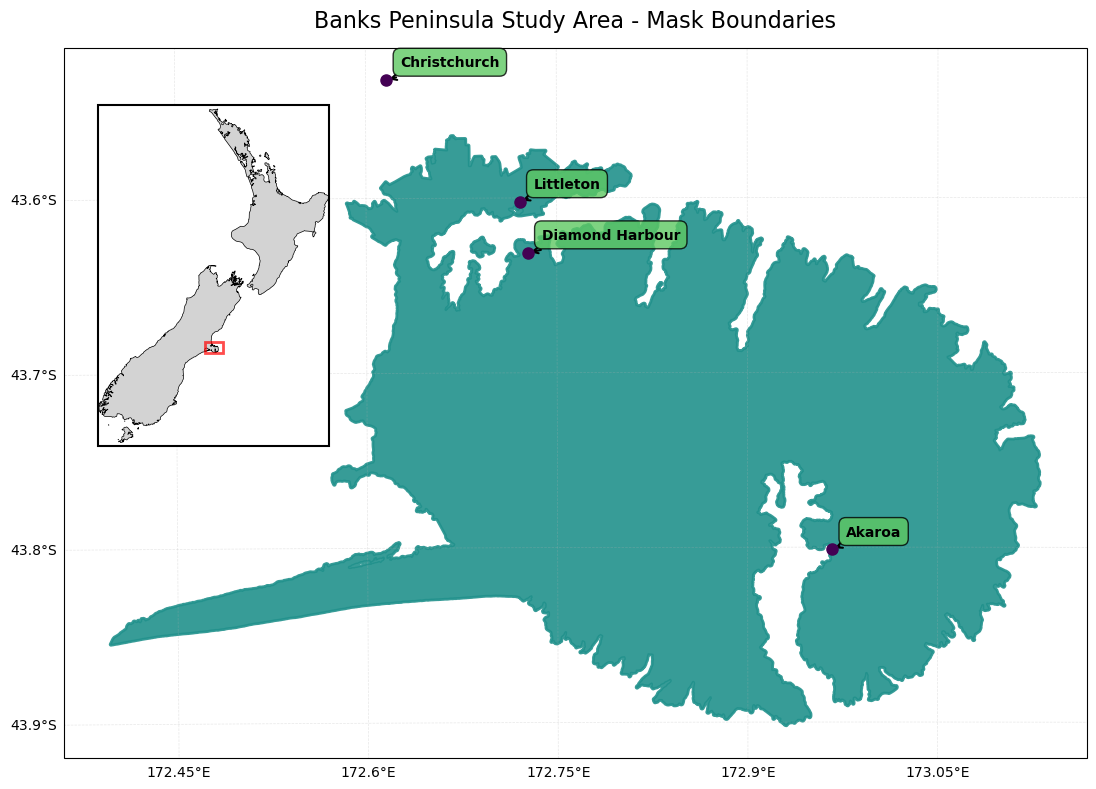

In [39]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

# Plot banks with a fill
banks_2193.plot(ax=ax, color=color_list[2], edgecolor=color_list[2], linewidth=2, alpha=0.9, label='Bank Mask Area')

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

# Define key location coordinates (in EPSG:2193)
locations = {
    'Christchurch': (1569000, 5180000),
    'Littleton': (1577471, 5172284),
    'Diamond Harbour': (1577981, 5169036),
    'Akaroa': (1597314, 5150196)
}

# Plot location markers and labels
for name, (x, y) in locations.items():
    ax.plot(x, y, 'o', color=color_list[0], markersize=8, transform=ccrs.epsg(2193), zorder=5)
    ax.annotate(name, xy=(x, y), xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color_list[3], alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5),
                transform=ccrs.epsg(2193))

ax.set_title('Banks Peninsula Study Area - Mask Boundaries', fontsize=16, pad=15)

# Create inset map showing location in New Zealand
axins = inset_axes(ax, width="50%", height="50%", loc='center left',
                   bbox_to_anchor=(-0.1, 0.2, 0.96, 0.96),
                   bbox_transform=ax.transAxes,
                   axes_class=cartopy.mpl.geoaxes.GeoAxes,
                   axes_kwargs=dict(projection=ccrs.epsg(2193)))

# Add New Zealand coastline or base map to inset
# Option 1: If you have a New Zealand shapefile/geodataframe (e.g., nz_coastline):
# nz_coastline.plot(ax=axins, facecolor='lightgray', edgecolor='black', linewidth=0.5)

# Option 2: Use cartopy's natural earth features
axins.add_feature(cartopy.feature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
axins.add_feature(cartopy.feature.OCEAN, facecolor='none')

# Set extent to show all of New Zealand (approximate bounds in EPSG:2193)
# These coordinates cover the main islands of New Zealand
axins.set_extent([1090000, 2090000, 4730000, 6230000], crs=ccrs.epsg(2193))

# Plot the Banks Peninsula area as a red box on the inset
banks_bounds = banks_2193.total_bounds  # [minx, miny, maxx, maxy]
rect = plt.Rectangle((banks_bounds[0], banks_bounds[1]), 
                      banks_bounds[2] - banks_bounds[0] + 20000,
                      banks_bounds[3] - banks_bounds[1] + 10000,
                      linewidth=2, edgecolor='red', facecolor='none', 
                     alpha = 0.7, transform=ccrs.epsg(2193), zorder=10)
axins.add_patch(rect)

# Remove tick labels from inset
axins.set_xticks([])
axins.set_yticks([])

# Optional: Add a border to the inset
for spine in axins.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('Plots/banks_mask_area.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

## Plotting reduction statistics 

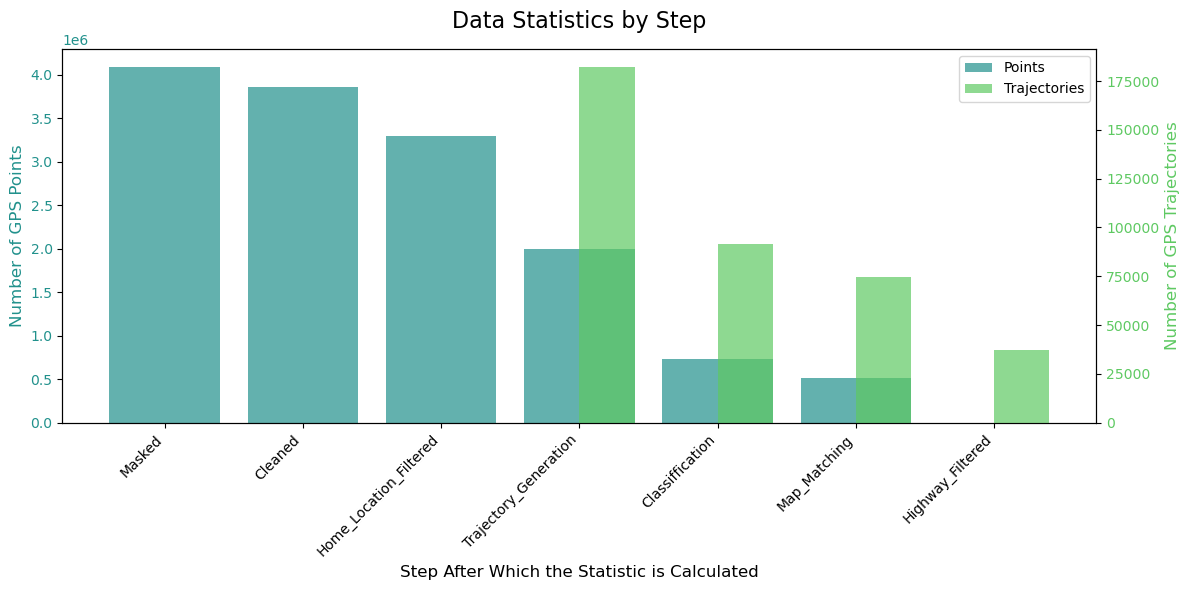

In [43]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot first column on left y-axis
color1 = color_list[2]
ax1.set_xlabel('Step After Which the Statistic is Calculated', fontsize=12)
ax1.set_ylabel('Number of GPS Points', color=color1, fontsize=12)
ax1.bar(range(len(reduction_stats)), reduction_stats.iloc[:, 1], alpha=0.7, color=color1, label=reduction_stats.columns[1])
ax1.tick_params(axis='y', labelcolor=color1)

# Create second y-axis for second column
ax2 = ax1.twinx()
color2 = color_list[3]
ax2.set_ylabel('Number of GPS Trajectories', color=color2, fontsize=12)
ax2.bar(range(len(reduction_stats)), reduction_stats.iloc[:, 2], alpha=0.7, color=color2, label=reduction_stats.columns[2], width=0.4, align='edge')
ax2.tick_params(axis='y', labelcolor=color2)

# Set x-axis labels
ax1.set_xticks(range(len(reduction_stats)))
ax1.set_xticklabels(reduction_stats.iloc[:, 0], rotation=45, ha='right')

# Add title and legend
plt.title('Data Statistics by Step', fontsize=16, pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.savefig('Plots/reduction_stats_plot.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

## Matching Plot

In [45]:
point = Point([1574322, 5160915])
location_gdf = gpd.GeoDataFrame(geometry=[point], crs='EPSG:2193')

In [46]:
# Finding nearest track segment to a point
nearest = gpd.sjoin_nearest(location_gdf, match_results_subset, how='left')

In [47]:
nearest_trajectorys = match_results_subset[match_results_subset['id']==nearest.iloc[0]['id']]

In [48]:
nearest_trajectorys.geometry = nearest_trajectorys["trip_geometry"].apply(lambda x: shapely.wkt.loads(x))

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [55]:
nearest.iloc[0]['id']

'7579'

In [57]:
osm_routes_2193[osm_routes_2193.index == 7579]

,highway,geometry
7579,path,"LINESTRING (1575214.905 5161186.847, 1575194.5..."


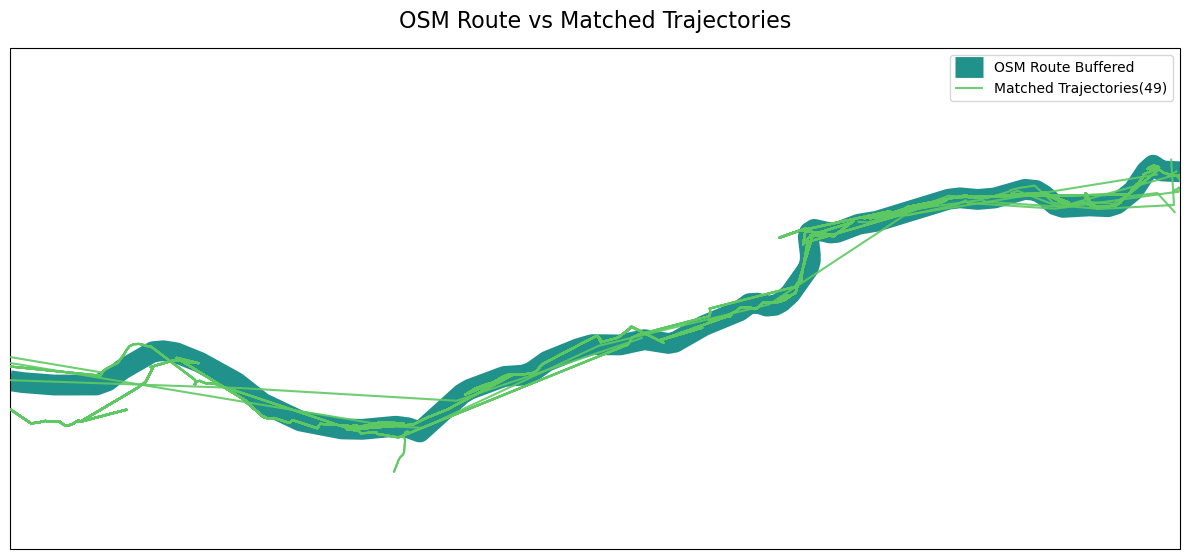

In [60]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.epsg(2193)})

# Plot OSM route
osm_subset = osm_routes_2193[osm_routes_2193.index == 7579]
osm_subset.geometry.plot(ax=ax, color=color_list[2], linewidth=15, label='OSM Route Buffered', zorder=2)

# Plot matched trajectories
nearest_trajectorys.geometry.plot(ax=ax, color=color_list[3], linewidth=1.5, alpha=0.9, label=f'Matched Trajectories({len(nearest_trajectorys)})', zorder=5, linestyle='-')

# Set extent and styling
bounds = osm_subset.total_bounds
# Add 10% buffer to bounds
buffer = (bounds[2] - bounds[0]) * 0.1
buffered_bounds = [bounds[0], bounds[2], bounds[1] - buffer, bounds[3] + buffer]
ax.set_extent(buffered_bounds, crs=ccrs.epsg(2193))
# ax.gridlines(draw_labels=True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
plt.title('OSM Route vs Matched Trajectories', fontsize=16, pad=15)
plt.tight_layout()

plt.savefig('Plots/Matching_Example.svg', format='svg', dpi=300, bbox_inches='tight')

## Plotting Maps of Frequency

### Count instances of trips on each route

In [61]:
route_counts = (
    match_results_subset
    .groupby("id", as_index=False)
    .agg(
        count=("id", "size"),
        geometry=("geometry", "first")
    )
)

route_counts = gpd.GeoDataFrame(route_counts, geometry="geometry", crs=match_results_subset.crs)
route_counts["count_log"] = route_counts["count"].replace(0, np.nan)

### Whole Area

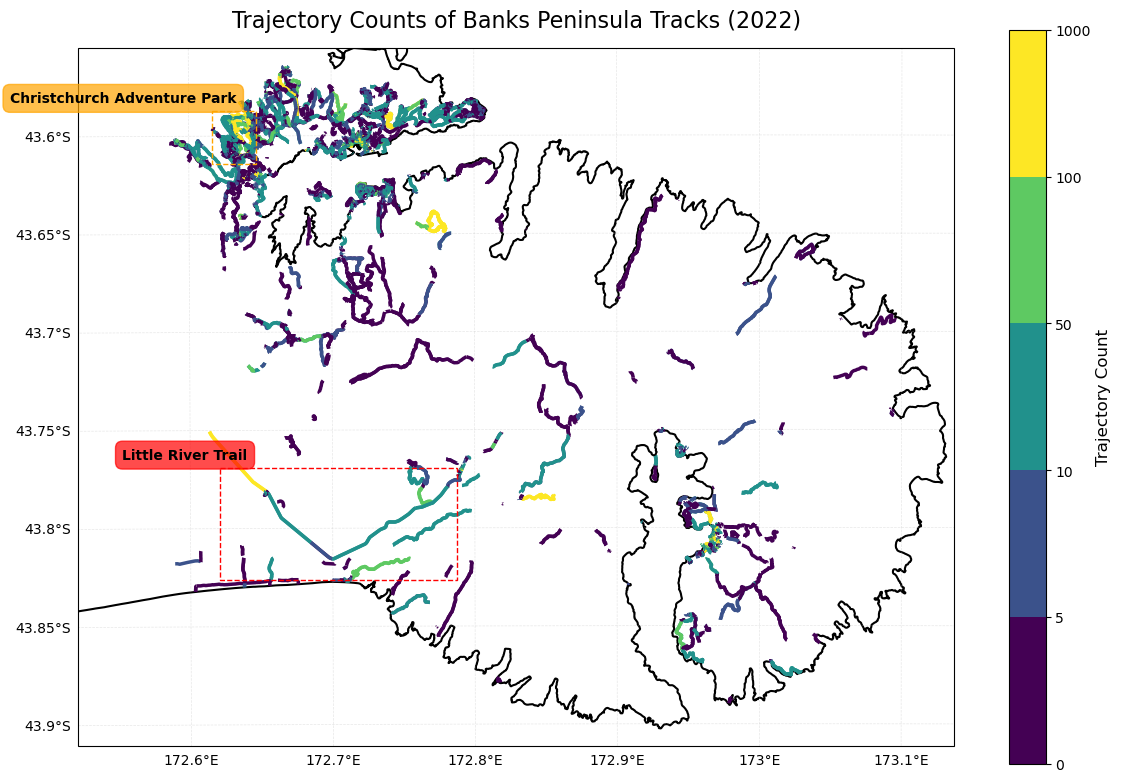

In [92]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

# Start map with the coastlines
coast_2193.plot(color="black", ax=ax, linewidth=1.5)

# Define discrete boundaries for the 5 colors
# This creates 5 color bins: [min-5], [5-10], [10-50], [50-100], [100-max]
boundaries = [
    0,
    5,
    10,
    50,
    100,
    1000
]
norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N)

# Plot colored frequency data
route_counts.plot(
    column="count_log",     
    ax=ax,
    cmap=discrete_cmap,
    linewidth=2.5,
    norm=norm,  # Use BoundaryNorm instead of LogNorm
    legend=True,
    legend_kwds={
        "label": "Trajectory Count",
    },
    zorder=3
)
cbar = ax.get_figure().get_axes()[1]  # Get the colorbar axis
cbar.set_ylabel("Trajectory Count", fontsize=12)  # Change label size

# Plot subplot bounds
# Little River Trail bounds
lr_rect = Rectangle(
    (LITTLE_RIVER_TRAIL_BOUNDS[0], LITTLE_RIVER_TRAIL_BOUNDS[2]),
    LITTLE_RIVER_TRAIL_BOUNDS[1] - LITTLE_RIVER_TRAIL_BOUNDS[0],
    LITTLE_RIVER_TRAIL_BOUNDS[3] - LITTLE_RIVER_TRAIL_BOUNDS[2],
    linewidth=1, edgecolor='red', facecolor='none', linestyle='--', 
    transform=ccrs.epsg(2193), zorder=4, label='Little River Trail'
)
ax.add_patch(lr_rect)

# Bike Park bounds
bp_rect = Rectangle(
    (BIKE_PARK_BOUNDS[0], BIKE_PARK_BOUNDS[2]),
    BIKE_PARK_BOUNDS[1] - BIKE_PARK_BOUNDS[0],
    BIKE_PARK_BOUNDS[3] - BIKE_PARK_BOUNDS[2],
    linewidth=1, edgecolor='orange', facecolor='none', linestyle='--',
    transform=ccrs.epsg(2193), zorder=4, label='Christchurch Adventure Park'
)
ax.add_patch(bp_rect)

# Add labels for bounding boxes
ax.text(LITTLE_RIVER_TRAIL_BOUNDS[0] - 2000,
        LITTLE_RIVER_TRAIL_BOUNDS[2] + 500,
        'Little River Trail',
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.7, edgecolor='red'),
        transform=ccrs.epsg(2193), zorder=6)

ax.text(BIKE_PARK_BOUNDS[0] - 5000,
        BIKE_PARK_BOUNDS[2] + 500,
        'Christchurch Adventure Park',
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='orange', alpha=0.7, edgecolor='orange'),
        transform=ccrs.epsg(2193), zorder=6)

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Trajectory Counts of Banks Peninsula Tracks (2022)', fontsize=16, pad=15)

ax.set_extent(BANKS_BOUNDS, crs=ccrs.epsg(2193))
plt.tight_layout()
plt.savefig('Plots/Banks_Peninsula_Frequency_Map.svg', format='svg', dpi=300, bbox_inches='tight')

### Bike Park

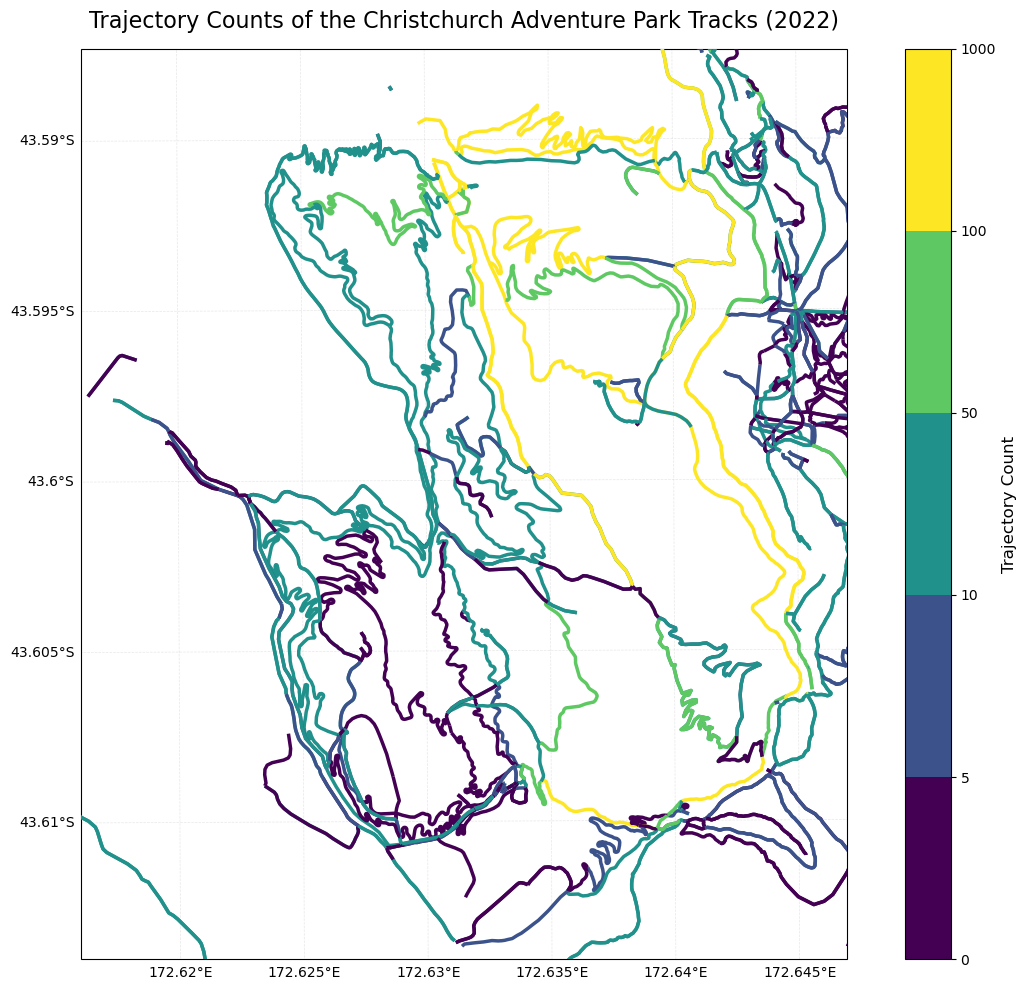

In [75]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

# Start map with the coastlines
coast_2193.plot(color="black", ax=ax, linewidth=1.5)

# Define discrete boundaries for the 5 colors
# This creates 5 color bins: [min-5], [5-10], [10-50], [50-100], [100-max]
boundaries = [
    0,
    5,
    10,
    50,
    100,
    1000
]
norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N)

# Plot colored frequency data
route_counts.plot(
    column="count_log",     
    ax=ax,
    cmap=discrete_cmap,
    linewidth=2.5,
    norm=norm,  # Use BoundaryNorm instead of LogNorm
    legend=True,
    legend_kwds={
        "label": "Trajectory Count",
    },
    zorder=3
)
cbar = ax.get_figure().get_axes()[1]  # Get the colorbar axis
cbar.set_ylabel("Trajectory Count", fontsize=12)  # Change label size

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


ax.set_title('Trajectory Counts of the Christchurch Adventure Park Tracks (2022)', fontsize=16, pad=15)

ax.set_extent(BIKE_PARK_BOUNDS, crs=ccrs.epsg(2193))
plt.tight_layout()
plt.savefig('Plots/Bike_Park_Frequency_Map.svg', format='svg', dpi=300, bbox_inches='tight')

### Little River

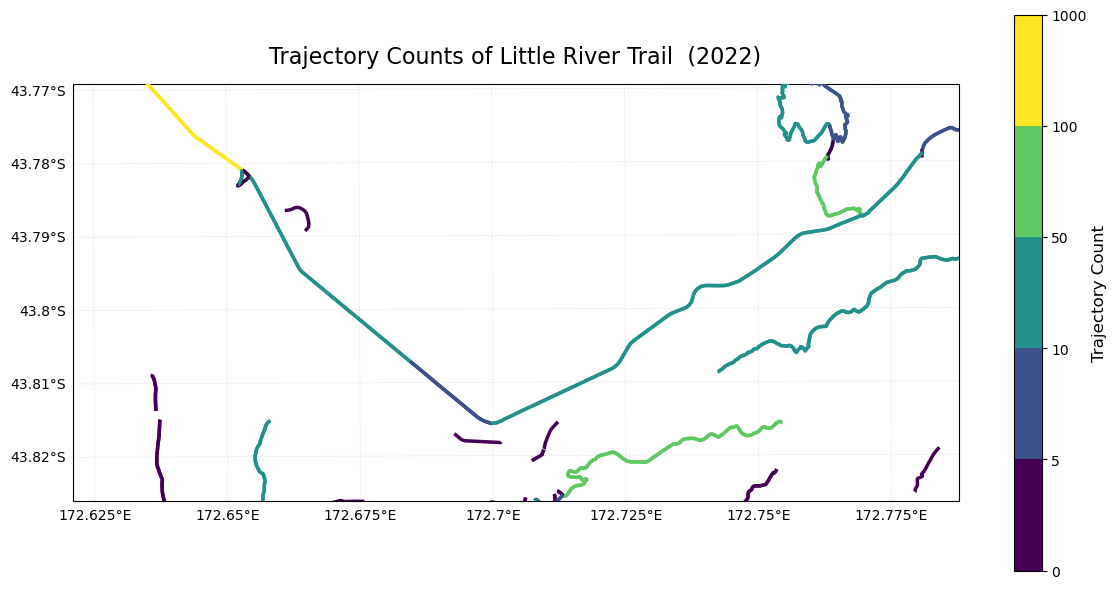

In [91]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

# Start map with the coastlines
coast_2193.plot(color="black", ax=ax, linewidth=1.5)

# Define discrete boundaries for the 5 colors
# This creates 5 color bins: [min-5], [5-10], [10-50], [50-100], [100-max]
boundaries = [
    0,
    5,
    10,
    50,
    100,
    1000
]
norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N)

# Plot colored frequency data
# route_counts_subset = route_counts[route_counts]
route_counts.plot(
    column="count_log",     
    ax=ax,
    cmap=discrete_cmap,
    linewidth=2.5,
    norm=norm,  # Use BoundaryNorm instead of LogNorm
    legend=True,
    legend_kwds={
        "label": "Trajectory Count",
    },
    zorder=3
)
cbar = ax.get_figure().get_axes()[1]  # Get the colorbar axis
cbar.set_ylabel("Trajectory Count", fontsize=12)  # Change label size

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


ax.set_title('Trajectory Counts of Little River Trail  (2022)', fontsize=16, pad=15)

ax.set_extent(LITTLE_RIVER_TRAIL_BOUNDS, crs=ccrs.epsg(2193))
plt.tight_layout()
plt.savefig('Plots/Little_River_Trail_Frequency_Map.svg', format='svg', dpi=300, bbox_inches='tight')

## Plotting Counter Locations

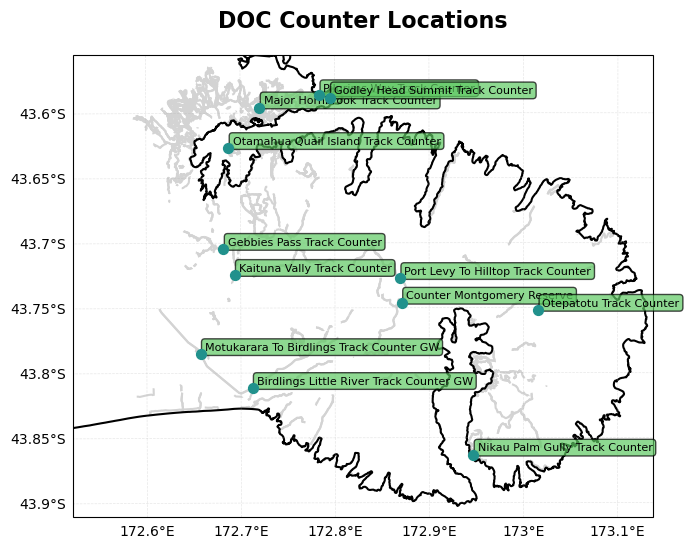

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))
# Start map with the coastlines
coast_2193.plot(color="black", ax=ax)
route_counts.plot(color = "lightgrey", ax=ax, linewidth=1.5, zorder=1)
Counter_Locations.plot(ax=ax, color=color_list[2], markersize=50, label='Counter Locations', zorder=5)

# Annotate counter locations with their names
for idx, row in Counter_Locations.iterrows():
    ax.annotate(text=row['Name'], xy=(row.geometry.x, row.geometry.y), 
                xytext=(3, 3), textcoords="offset points", fontsize=8, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color_list[3], alpha=0.7),
                arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=0", lw=0.5))

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


ax.set_title('DOC Counter Locations', fontsize = 16, fontweight='bold', pad=20)

ax.set_extent(BANKS_BOUNDS, crs=ccrs.epsg(2193))
plt.savefig('Plots/Counter_Locations.svg', format='svg', dpi=300, bbox_inches='tight')

## Time Series Comparison: Counter Data vs Match Results

In [93]:
def plot_counter_comparison(tech_id, counter_data, match_results, counter_locations):
    """
    Plot time series comparison of counter data and match results for a given tech_id

    Parameters:
    - tech_id: The tech ID to filter on
    - counter_data: DataFrame with columns ['Techid', 'Datetime', 'Count']
    - match_results: DataFrame with columns ['id', 'middle_time'] (or 'timestamp')
    - counter_locations: DataFrame with columns ['Techid', 'cpath'] where cpath is a list of ids
    """
    # Get counter data for this tech_id
    counter_subset = counter_data[counter_data['Techid'].astype(str) == str(tech_id)].copy()
    # Use 'Datetime' and 'Count' per inspected schema
    counter_subset['timestamp'] = pd.to_datetime(counter_subset['Datetime'])
    counter_subset['count'] = counter_subset['Count']

    # Get all cpath ids for this tech_id, flatten across rows safely
    paths = counter_locations.loc[counter_locations['Techid'].astype(str) == str(tech_id), 'cpath']
    if paths.empty:
        print(f"No counter location found for Techid={tech_id}")
        return

    # Extract cpath - handle both list and string representations
    cpath_raw = paths.values[0] if len(paths) > 0 else []
    
    # If cpath is stored as a string, parse it
    if isinstance(cpath_raw, str):
        import ast
        try:
            cpath_list = ast.literal_eval(cpath_raw)
        except:
            # Try simple parsing if ast fails
            cpath_list = [x.strip().strip("'\"") for x in cpath_raw.strip("[]").split(',')]
    elif isinstance(cpath_raw, list):
        cpath_list = cpath_raw
    else:
        cpath_list = []
    
    # Ensure all ids are strings to match mr['id']
    cpath_ids = [str(x).strip() for x in cpath_list if x]
    
    print(f"Debug - cpath_ids: {cpath_ids}")
    print(f"Debug - Number of cpath_ids: {len(cpath_ids)}")
    
    # Filter match_results by ids in cpath and count occurrences per timestamp
    mr = match_results.copy()
    
    print(f"Debug - mr['id'] sample: {mr['id'].head(3).tolist()}")
    print(f"Debug - Any matches? {mr['id'].isin(cpath_ids).sum()}")
    
    # Prefer 'middle_time' if present, fall back to 'timestamp' or 'Datetime'
    if 'middle_time' in mr.columns:
        mr['timestamp'] = pd.to_datetime(mr['middle_time'], utc=True)
    elif 'timestamp' in mr.columns:
        mr['timestamp'] = pd.to_datetime(mr['timestamp'], utc=True)
    else:
        mr['timestamp'] = pd.to_datetime(mr['Datetime'], utc=True)

    # Match without type conversion first
    match_subset = mr[mr['id'].isin(cpath_ids)].copy()

    # Group by month for both datasets
    counter_subset['month'] = counter_subset['timestamp'].dt.month
    match_subset['month'] = match_subset['timestamp'].dt.month
    
    # Aggregate by month
    counter_monthly = counter_subset.groupby('month')['count'].sum().reindex(range(1, 13), fill_value=0)
    match_monthly = match_subset.groupby('month').size().reindex(range(1, 13), fill_value=0)
    
    # Calculate total counts
    counter_total = counter_monthly.sum()
    match_total = match_monthly.sum()
    
    # Normalize both series
    counter_norm = sklearn.preprocessing.minmax_scale(counter_monthly)
    match_norm = sklearn.preprocessing.minmax_scale(match_monthly)
    
    # Calculate zero-lag Pearson correlation
    from scipy.stats import pearsonr
    if len(counter_monthly) > 1 and match_monthly.sum() > 0:
        corr, _ = pearsonr(counter_monthly.values, match_monthly.values)
    else:
        corr = np.nan

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Month labels
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    # Plot counter data
    ax.plot(range(12), counter_norm,
            label=f'Counter Data (Total: {counter_total:.0f})', 
            marker='o', linewidth=2, color = color_list[2])
    
    # Plot match results
    ax.plot(range(12), match_norm,
            label=f'Match Results (Total: {match_total:.0f})', 
            marker='s', linewidth=2, color = color_list[3])

    ax.set_xticks(range(12))
    ax.set_xticklabels(months)
    ax.set_xlabel('Month',fontsize = 12)
    ax.set_ylabel('Normalized Count',fontsize = 12)
    corr_str = f' (r={corr:.3f})' if not np.isnan(corr) else ''
    ax.set_title(f'Counter Comparison for {counter_locations[counter_locations["Techid"].astype(str) == str(tech_id)]["Name"].values[0]} (Normalized Monthly){corr_str}',fontsize=16, pad=15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

Processing 12 tech IDs...
Processing Tech ID: 394796
Debug - cpath_ids: ['2494', '2431']
Debug - Number of cpath_ids: 2
Debug - mr['id'] sample: ['1', '1', '1']
Debug - Any matches? 3
Saved: Plots/counter_comparison_394796.svg
Processing Tech ID: 28638
Debug - cpath_ids: ['3970']
Debug - Number of cpath_ids: 1
Debug - mr['id'] sample: ['1', '1', '1']
Debug - Any matches? 2
Saved: Plots/counter_comparison_28638.svg
Processing Tech ID: 305961
Debug - cpath_ids: ['10336']
Debug - Number of cpath_ids: 1
Debug - mr['id'] sample: ['1', '1', '1']
Debug - Any matches? 28
Saved: Plots/counter_comparison_305961.svg
Processing Tech ID: 304795
Debug - cpath_ids: ['10562']
Debug - Number of cpath_ids: 1
Debug - mr['id'] sample: ['1', '1', '1']
Debug - Any matches? 14
Saved: Plots/counter_comparison_304795.svg
Processing Tech ID: 88470
Debug - cpath_ids: ['7579', '7594']
Debug - Number of cpath_ids: 2
Debug - mr['id'] sample: ['1', '1', '1']
Debug - Any matches? 106
Saved: Plots/counter_comparison_8

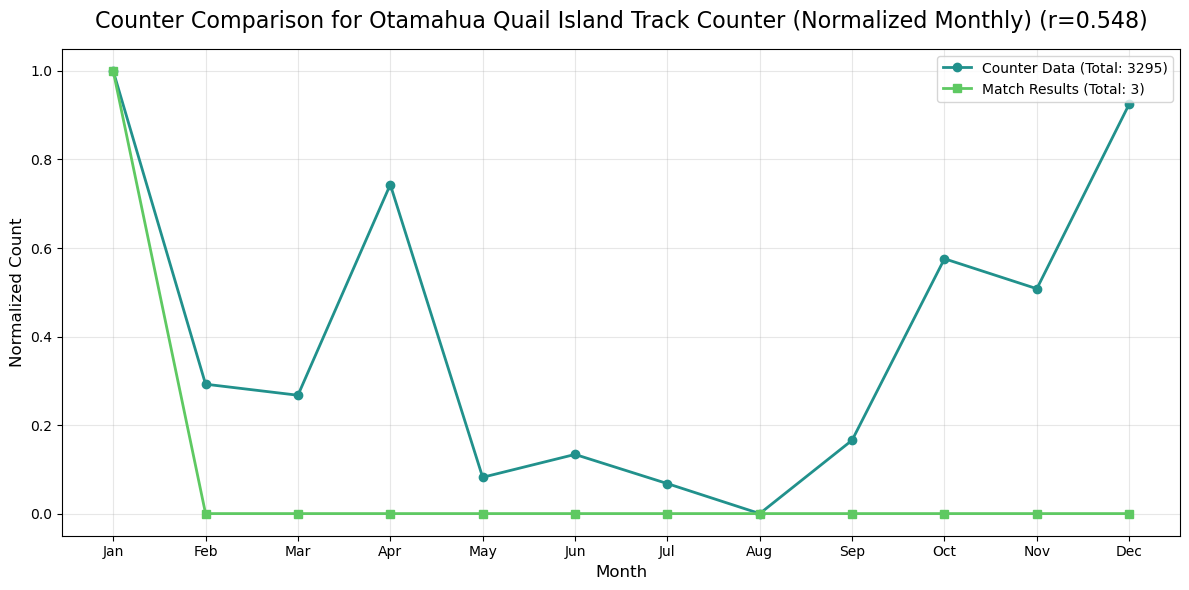

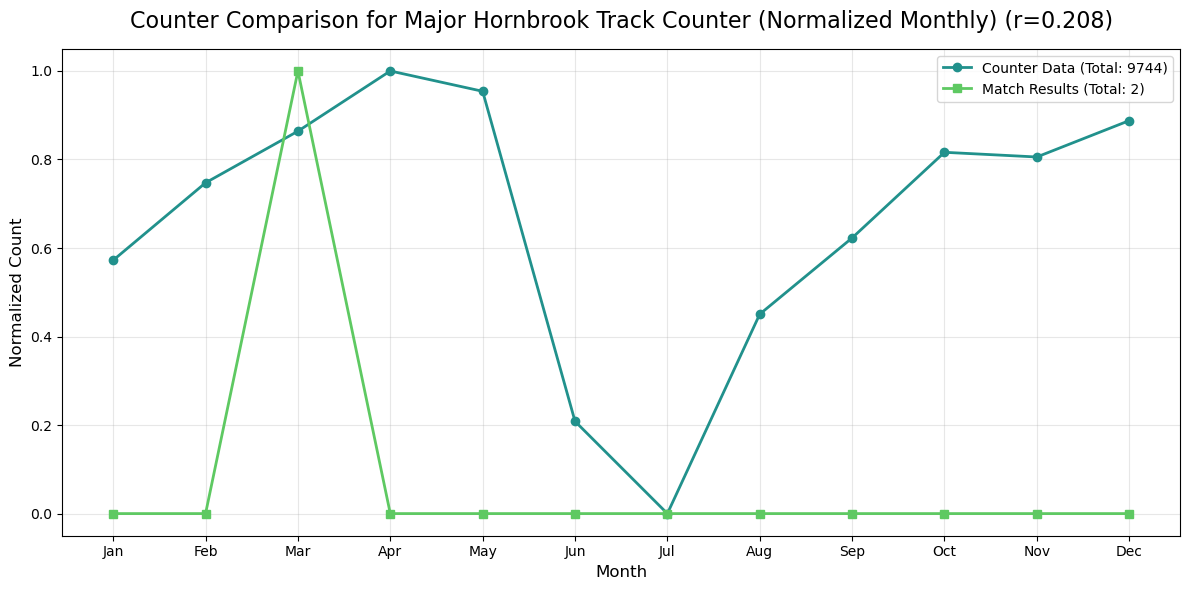

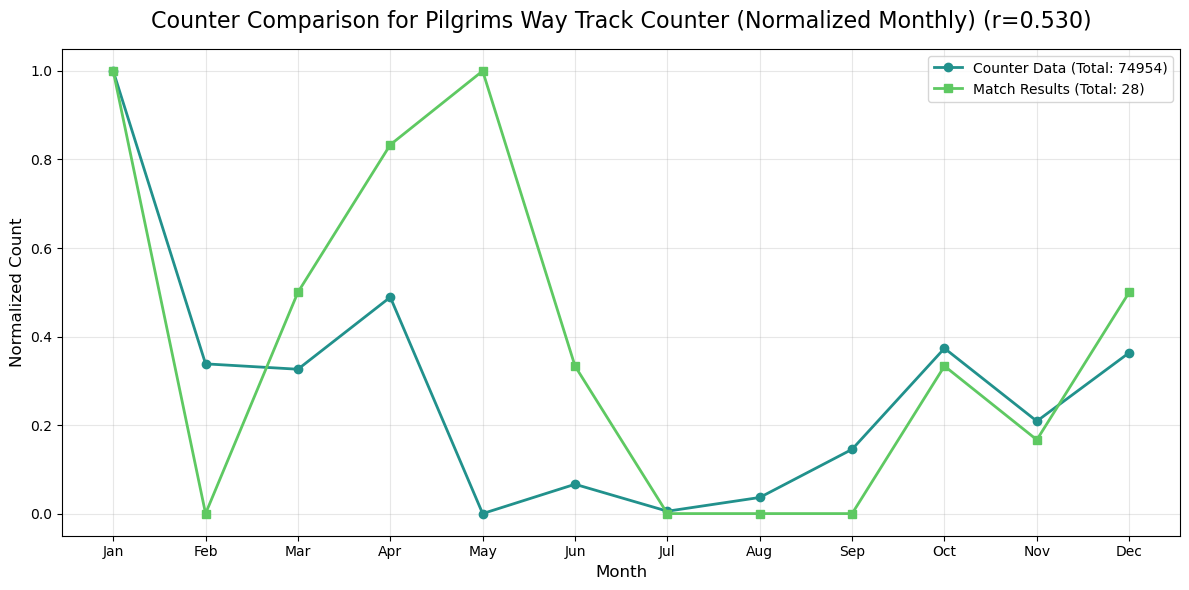

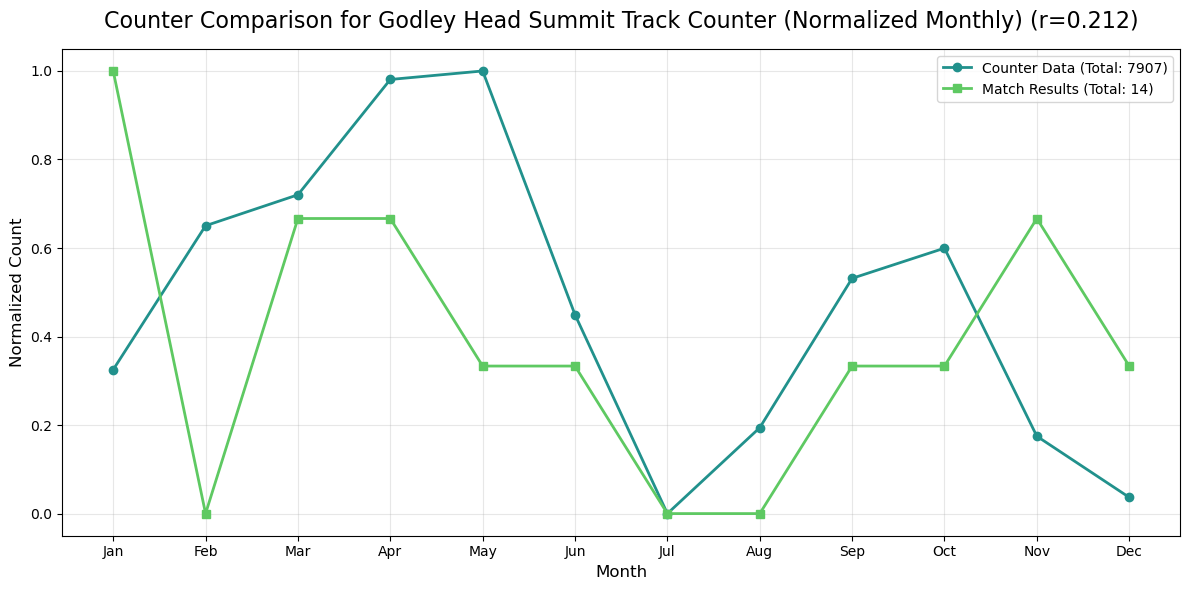

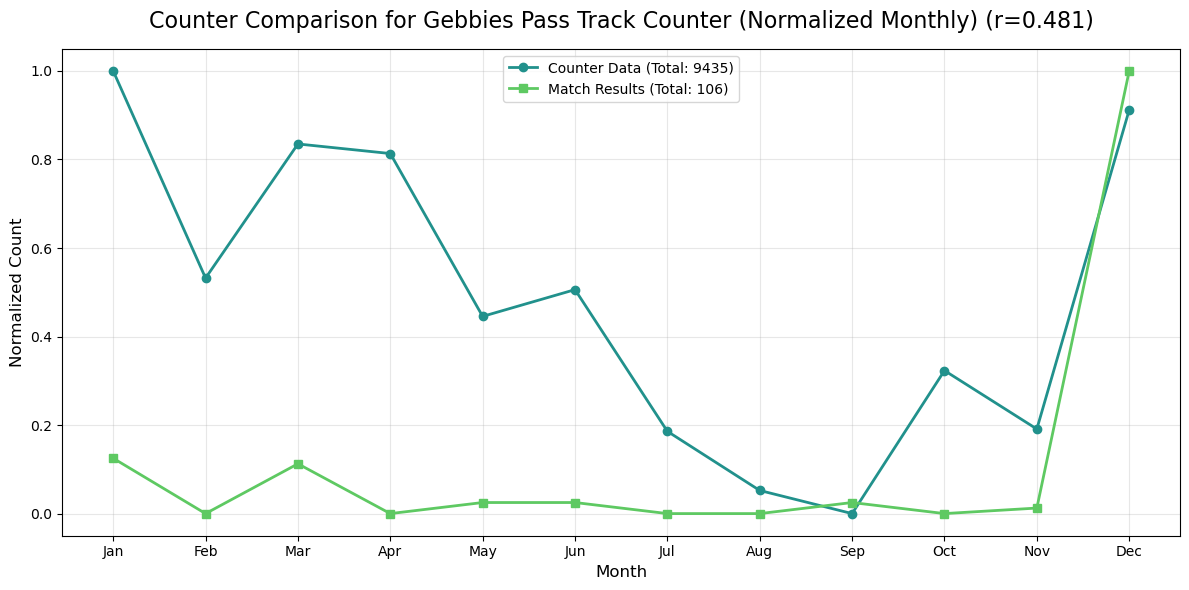

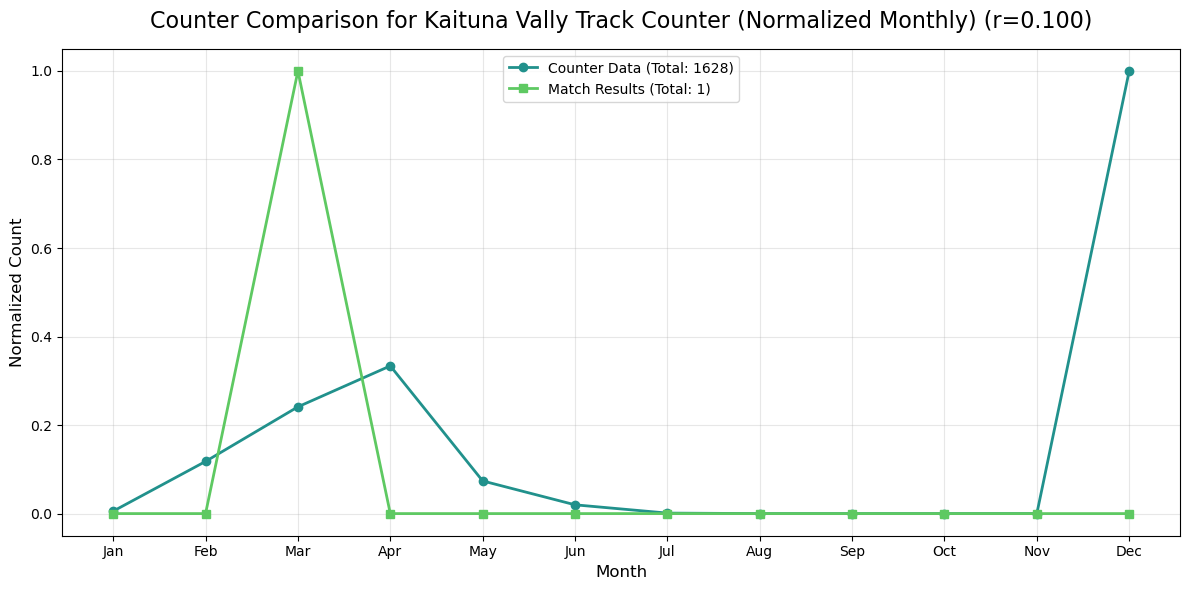

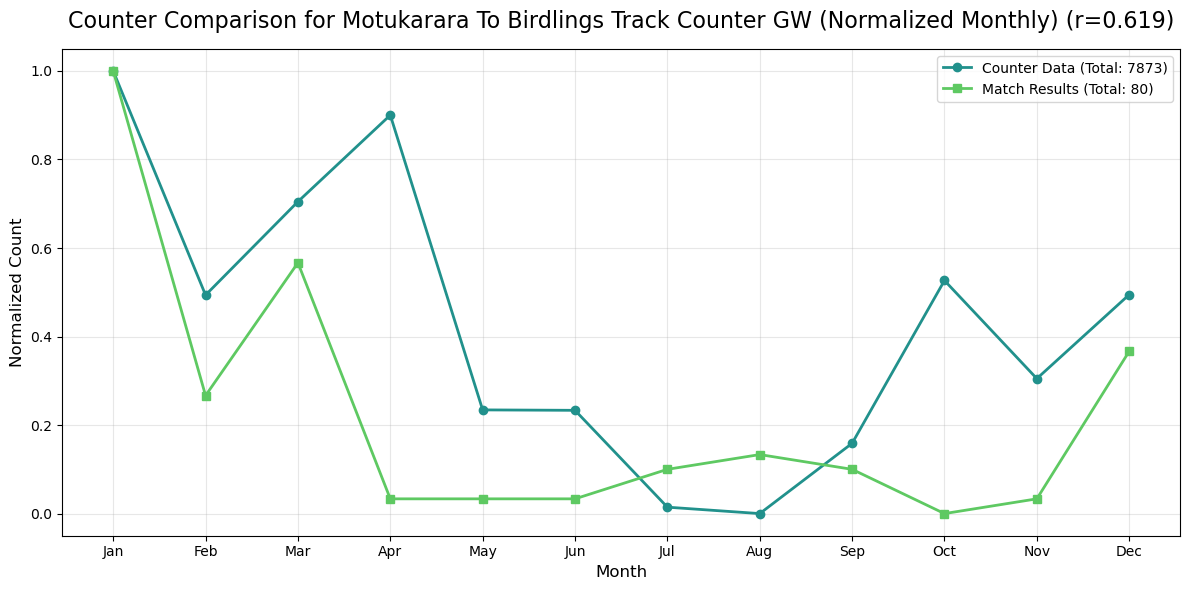

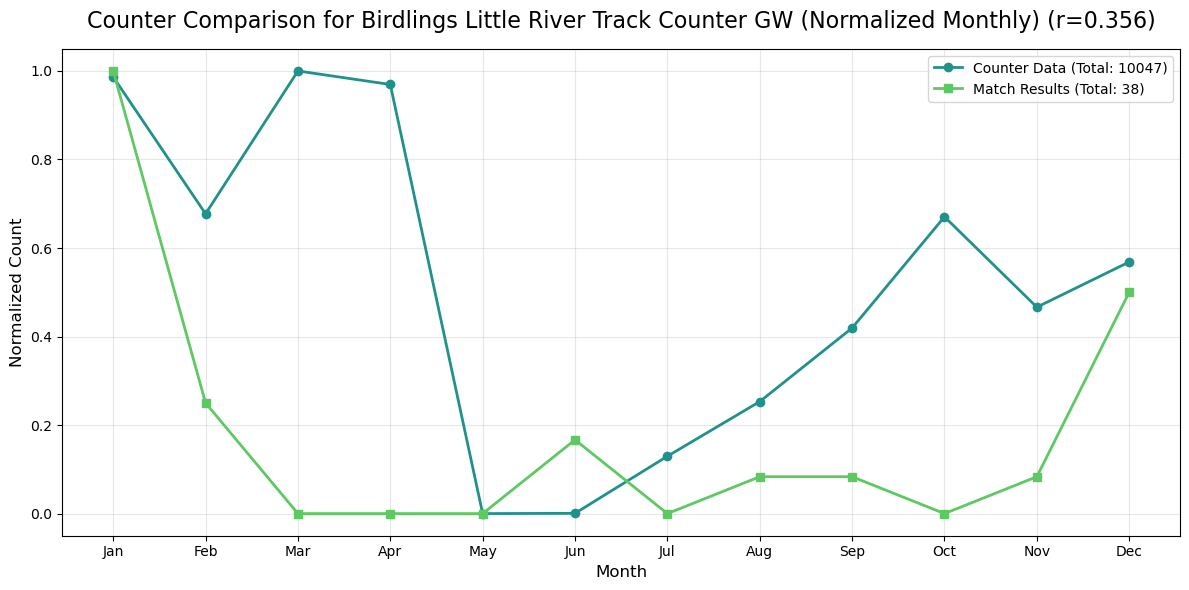

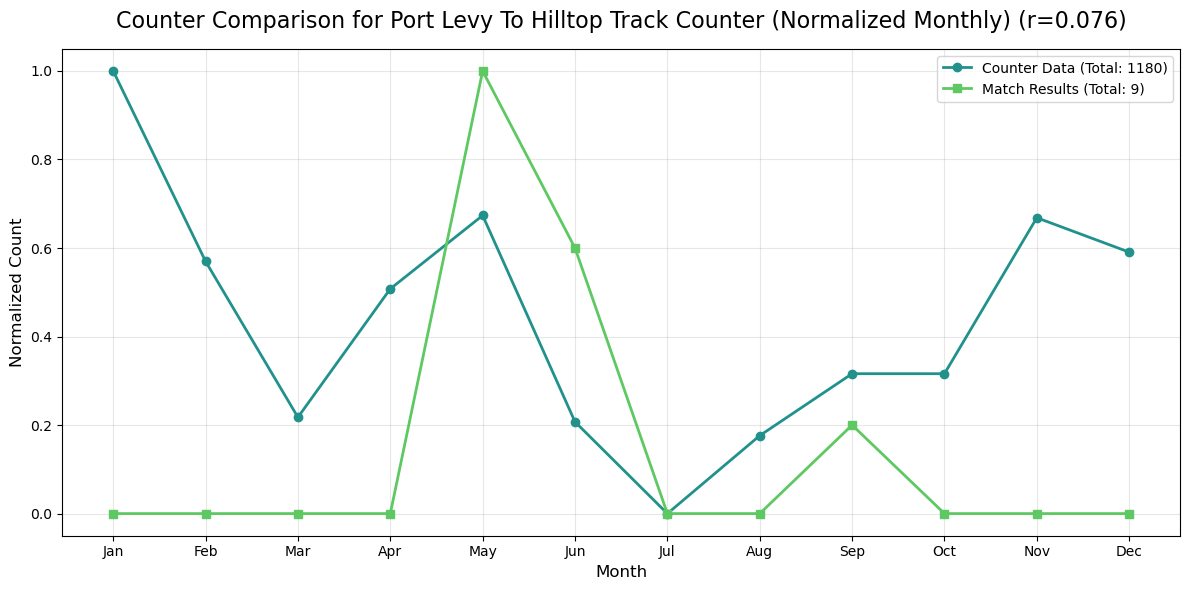

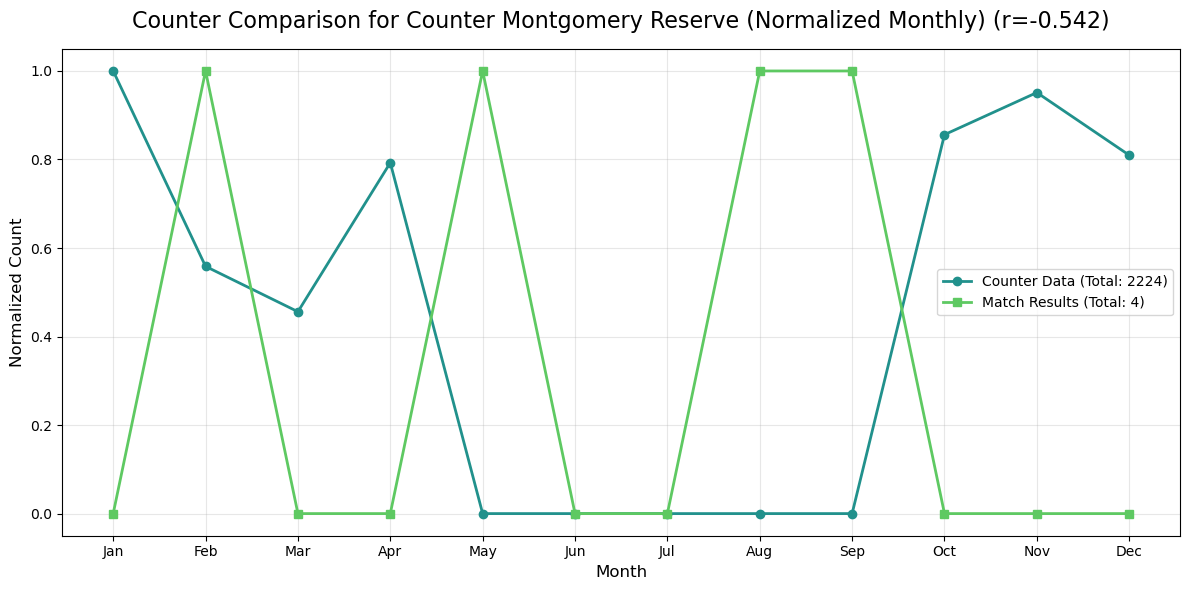

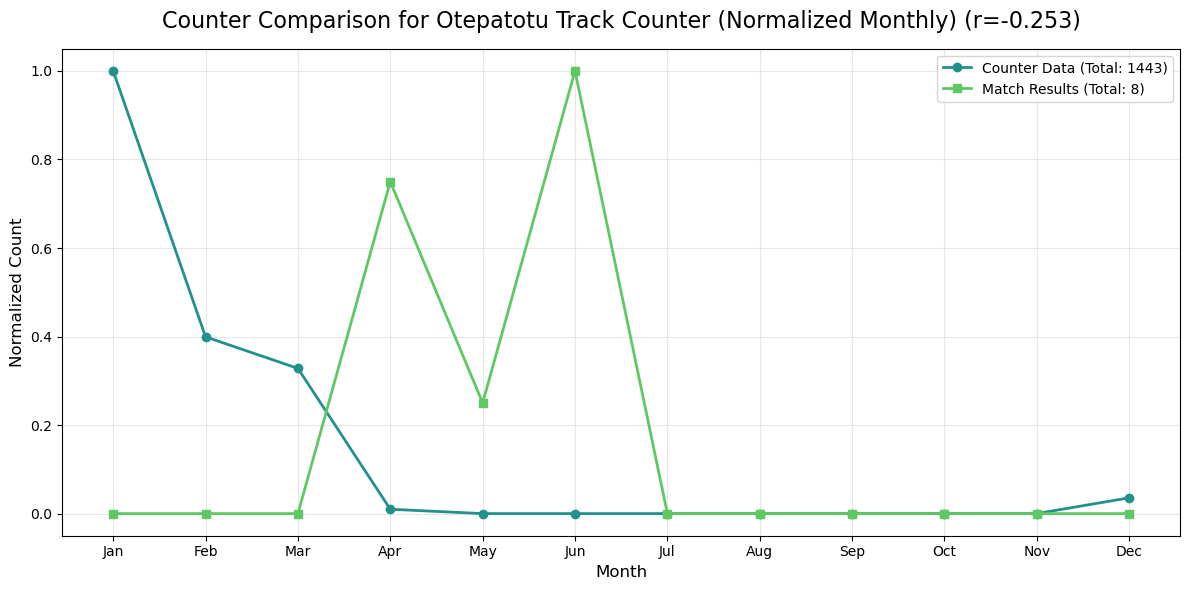

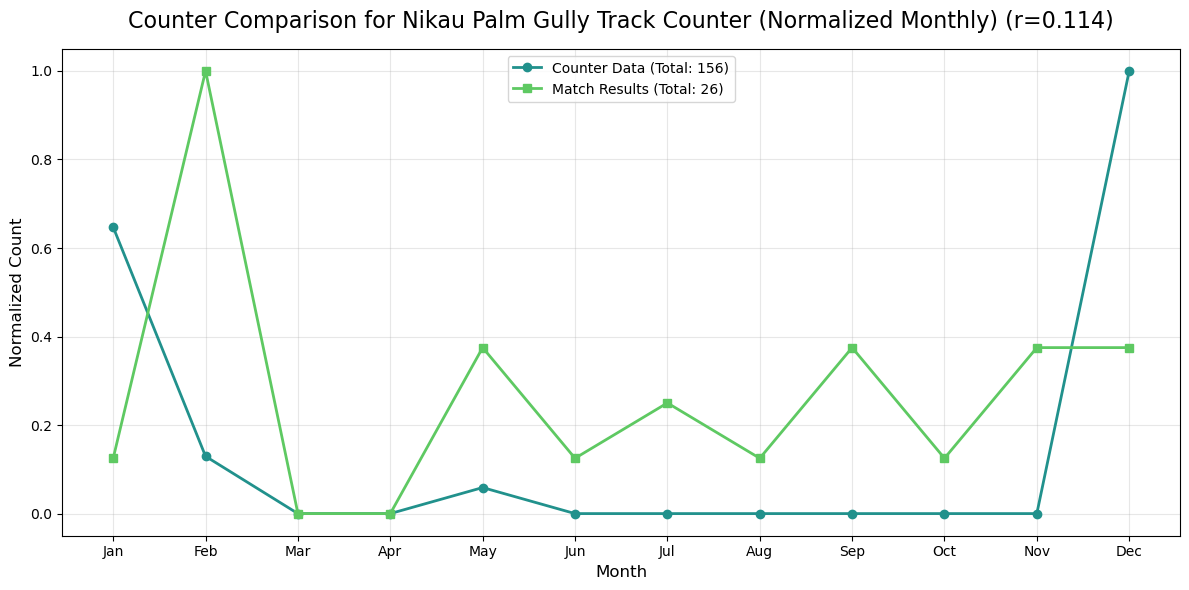

In [94]:

# Loop through all tech IDs and save plots as SVG
tech_ids = Counter_Locations['Techid'].unique()
print(f"Processing {len(tech_ids)} tech IDs...")

for tech_id in tech_ids:
    print(f"Processing Tech ID: {tech_id}")
    plot_counter_comparison(str(tech_id), Counter_data, match_results, Counter_Locations)
    # Save as SVG
    output_path = f'Plots/counter_comparison_{tech_id}.svg'
    plt.savefig(output_path, format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig)  # Close to free memory
    print(f"Saved: {output_path}")



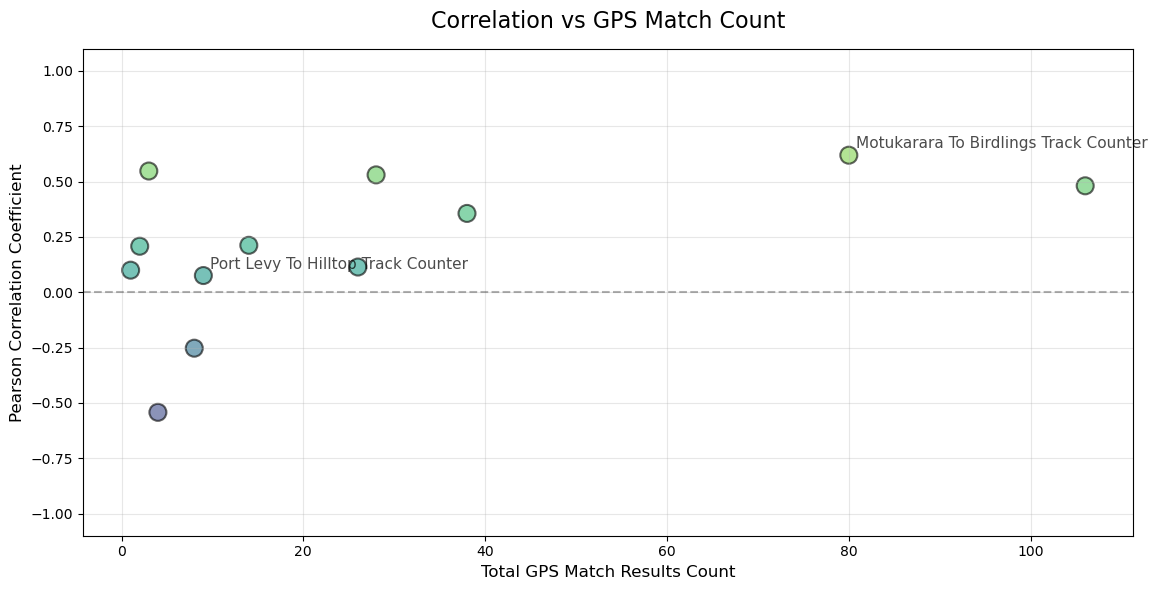

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Correlation vs GPS Match Count'}, xlabel='Total GPS Match Results Count', ylabel='Pearson Correlation Coefficient'>,
 [3, 2, 28, 14, 106, 1, 80, 38, 9, 4, 8, 26],
 [np.float64(0.5478690528186221),
  np.float64(0.2079716616336827),
  np.float64(0.5304446189259884),
  np.float64(0.21225304090094865),
  np.float64(0.48108162273231625),
  np.float64(0.09986294228805048),
  np.float64(0.6193759045525024),
  np.float64(0.3562839822825117),
  np.float64(0.07560067284898253),
  np.float64(-0.542480379249804),
  np.float64(-0.25266153746541686),
  np.float64(0.11406310926233232)])

In [119]:
def compute_zero_lag_correlation(tech_id, counter_data, match_results, counter_locations):
    """
    Compute zero-lag Pearson correlation between counter data and match results
    
    Parameters:
    - tech_id: The tech ID to filter on
    - counter_data: DataFrame with columns ['Techid', 'Datetime', 'Count']
    - match_results: DataFrame with columns ['id', 'middle_time']
    - counter_locations: DataFrame with columns ['Techid', 'cpath']
    
    Returns:
    - correlation coefficient, total match count, or (np.nan, 0) if insufficient data
    """
    from scipy.stats import pearsonr
    
    try:
        # Get counter data for this tech_id
        counter_subset = counter_data[counter_data['Techid'].astype(str) == str(tech_id)].copy()
        counter_subset['timestamp'] = pd.to_datetime(counter_subset['Datetime'])
        counter_subset['count'] = counter_subset['Count']
        
        # Get all cpath ids for this tech_id
        paths = counter_locations.loc[counter_locations['Techid'].astype(str) == str(tech_id), 'cpath']
        if paths.empty:
            return np.nan, 0
        
        # Extract and parse cpath
        cpath_raw = paths.values[0] if len(paths) > 0 else []
        if isinstance(cpath_raw, str):
            import ast
            try:
                cpath_list = ast.literal_eval(cpath_raw)
            except:
                cpath_list = [x.strip().strip("'\"") for x in cpath_raw.strip("[]").split(',')]
        elif isinstance(cpath_raw, list):
            cpath_list = cpath_raw
        else:
            cpath_list = []
        
        cpath_ids = [str(x).strip() for x in cpath_list if x]
        if not cpath_ids:
            return np.nan, 0
        
        # Filter match_results
        mr = match_results.copy()
        mr['id'] = mr['id'].astype(str)
        mr['timestamp'] = pd.to_datetime(mr['middle_time'], utc=True)
        match_subset = mr[mr['id'].isin(cpath_ids)].copy()
        
        total_match_count = len(match_subset)
        if total_match_count == 0:
            return np.nan, 0
        
        # Group by month
        counter_subset['month'] = counter_subset['timestamp'].dt.month
        match_subset['month'] = match_subset['timestamp'].dt.month
        
        counter_monthly = counter_subset.groupby('month')['count'].sum().reindex(range(1, 13), fill_value=0).values
        match_monthly = match_subset.groupby('month').size().reindex(range(1, 13), fill_value=0).values
        
        # Compute zero-lag Pearson correlation
        if len(counter_monthly) > 1:
            corr, _ = pearsonr(counter_monthly, match_monthly)
            return corr, total_match_count
        else:
            return np.nan, total_match_count
    except:
        return np.nan, 0


def plot_correlation_vs_count(counter_data, match_results, counter_locations):
    """
    Plot correlation coefficient vs total match count across all tech IDs
    Shows if correlation improves with larger match result counts
    
    Parameters:
    - counter_data: DataFrame with columns ['Techid', 'Datetime', 'Count']
    - match_results: DataFrame with columns ['id', 'middle_time']
    - counter_locations: DataFrame with columns ['Techid', 'cpath']
    """
    tech_ids = counter_locations['Techid'].unique()
    
    correlations = []
    counts = []
    tech_id_labels = []
    
    for tech_id in tech_ids:
        corr, count = compute_zero_lag_correlation(tech_id, counter_data, match_results, counter_locations)
        if not np.isnan(corr) and count > 0:
            correlations.append(corr)
            counts.append(count)
            tech_id_labels.append(str(tech_id))
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    scatter = ax.scatter(counts, correlations, s=150, alpha=0.6, c=correlations, cmap='viridis', 
                        vmin=-1, vmax=1, edgecolors='black', linewidth=1.5)
    
    
    # Add tech_id labels to points
    for i, label in enumerate(tech_id_labels):
        if (label == '34475') or (label == '34472'):
            ax.annotate(counter_locations["Name"][i], (counts[i], correlations[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=11, alpha=0.7)
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel('Total GPS Match Results Count',fontsize = 12)
    ax.set_ylabel('Pearson Correlation Coefficient',fontsize = 12)
    ax.set_title('Correlation vs GPS Match Count',fontsize = 16, pad = 15)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
   
    output_path = f'Plots/counter_correlation_plot.svg'
    plt.savefig(output_path, format='svg', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    return fig, ax, counts, correlations


# Example usage - plot correlation vs match count across all tech IDs
plot_correlation_vs_count(Counter_data, match_results, Counter_Locations)

## Global Time Series Comparisons
Comparing all counter data vs all match results organized by time (no tech ID filtering)


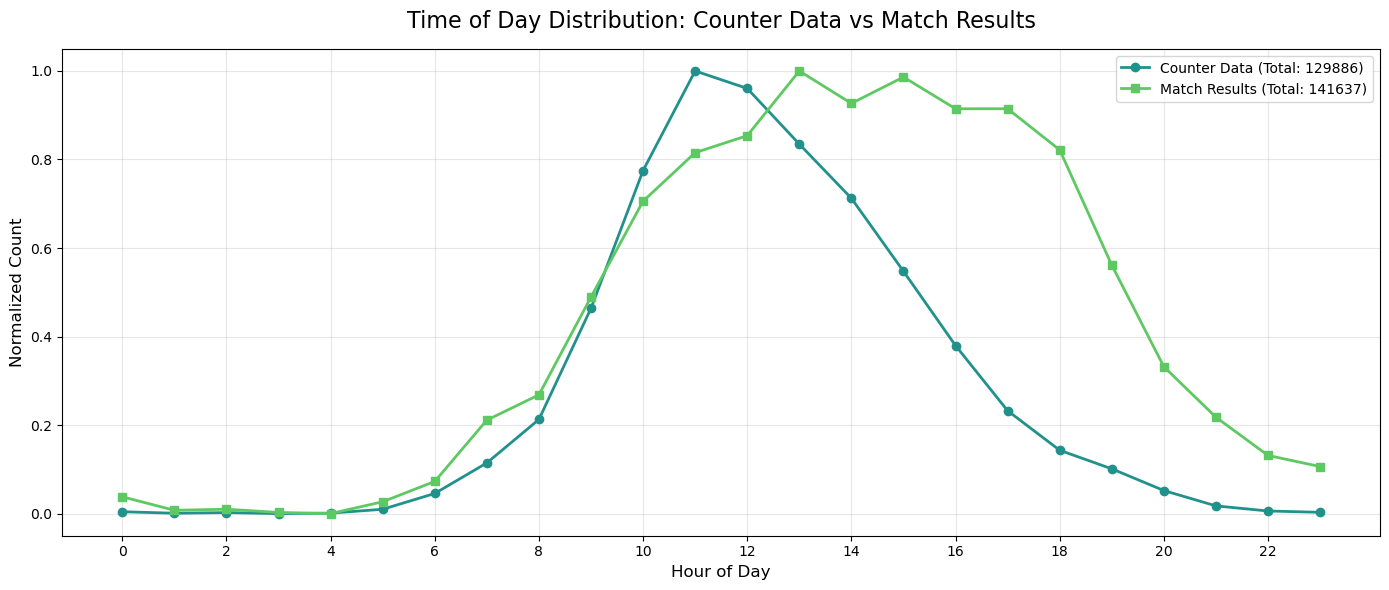

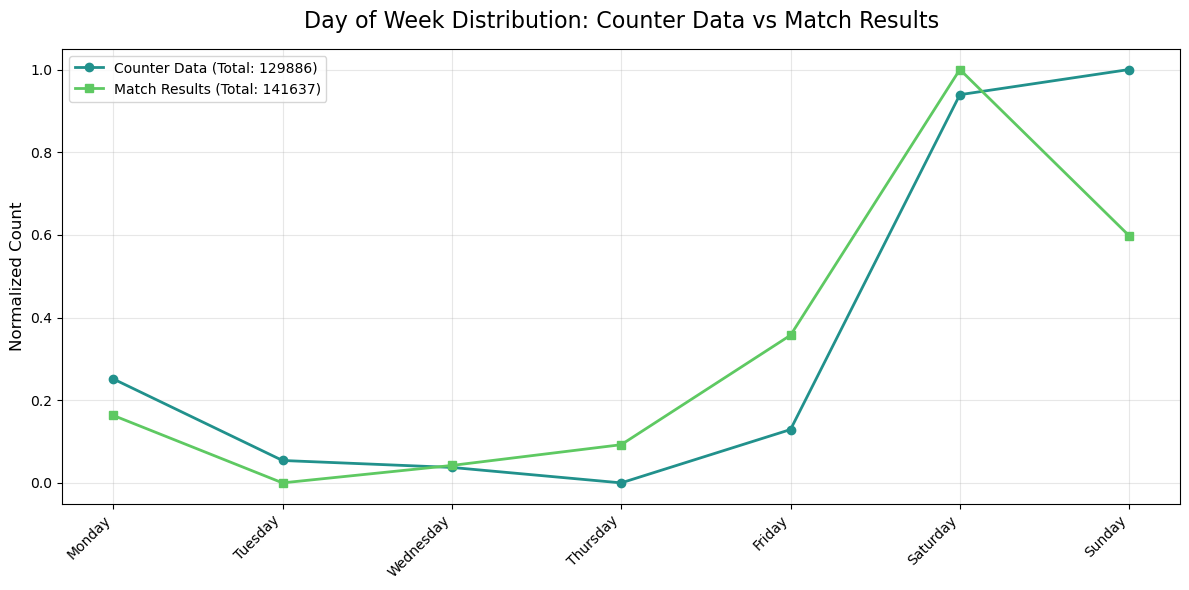

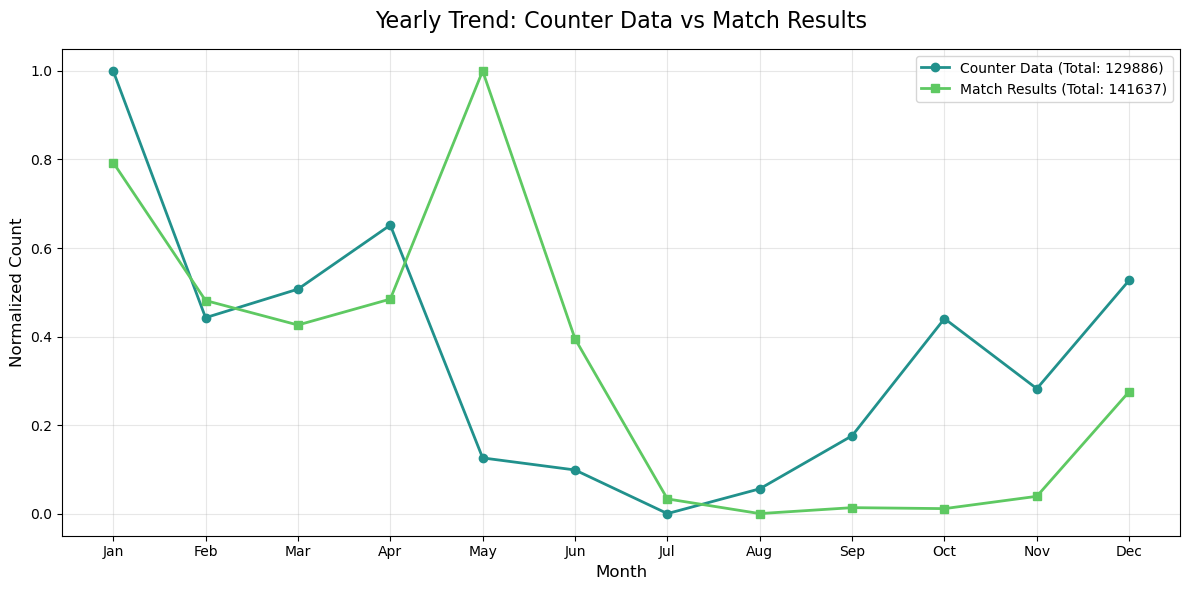

(<Figure size 1400x600 with 1 Axes>,
 <Figure size 1200x600 with 1 Axes>,
 <Figure size 1200x600 with 1 Axes>)

In [121]:
def plot_global_time_comparisons(counter_data, match_results):
    """
    Create three comparison plots for all data:
    1. Time of day (hour) distribution
    2. Day of week distribution
    3. Month distribution (yearly trend)
    
    Parameters:
    - counter_data: DataFrame with 'Datetime' and 'Count' columns
    - match_results: DataFrame with 'middle_time' column
    """
    from scipy.stats import pearsonr
    
    # Prepare counter data
    counter_subset = counter_data.copy()
    counter_subset['timestamp'] = pd.to_datetime(counter_subset['Datetime'])
    counter_subset['hour'] = counter_subset['timestamp'].dt.hour
    counter_subset['day_of_week'] = counter_subset['timestamp'].dt.day_name()
    counter_subset['month'] = counter_subset['timestamp'].dt.month
    
    # Prepare match results with timezone correction (+13 hours)
    mr = match_results.copy()
    mr['timestamp'] = pd.to_datetime(mr['middle_time'], utc=True) + pd.Timedelta(hours=13)
    mr['hour'] = mr['timestamp'].dt.hour
    mr['day_of_week'] = mr['timestamp'].dt.day_name()
    mr['month'] = mr['timestamp'].dt.month
    
    # Define day order
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    # ===== PLOT 1: Time of Day =====
    fig1, ax1 = plt.subplots(figsize=(14, 6))
    
    counter_hourly = counter_subset.groupby('hour')['Count'].sum().reindex(range(0, 24), fill_value=0)
    match_hourly = mr.groupby('hour').size().reindex(range(0, 24), fill_value=0)
    
    counter_norm_hourly = sklearn.preprocessing.minmax_scale(counter_hourly.values.reshape(-1, 1)).flatten()
    match_norm_hourly = sklearn.preprocessing.minmax_scale(match_hourly.values.reshape(-1, 1)).flatten()
    
    ax1.plot(range(24), counter_norm_hourly, marker='o', linewidth=2, 
             label=f'Counter Data (Total: {counter_hourly.sum():.0f})', color=color_list[2])
    ax1.plot(range(24), match_norm_hourly, marker='s', linewidth=2, 
             label=f'Match Results (Total: {match_hourly.sum():.0f})', color=color_list[3])
    
    ax1.set_xticks(range(0, 24, 2))
    ax1.set_xlabel('Hour of Day',fontsize = 12)
    ax1.set_ylabel('Normalized Count',fontsize = 12)
    ax1.set_title('Time of Day Distribution: Counter Data vs Match Results',fontsize = 16,pad = 15)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    fig1.tight_layout()
    plt.savefig('Plots/global_time_of_day_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== PLOT 2: Day of Week =====
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    counter_daily = counter_subset.groupby('day_of_week')['Count'].sum()
    match_daily = mr.groupby('day_of_week').size()
    
    # Reindex to proper day order
    counter_daily = counter_daily.reindex(day_order, fill_value=0)
    match_daily = match_daily.reindex(day_order, fill_value=0)
    
    counter_norm_daily = sklearn.preprocessing.minmax_scale(counter_daily.values.reshape(-1, 1)).flatten()
    match_norm_daily = sklearn.preprocessing.minmax_scale(match_daily.values.reshape(-1, 1)).flatten()
    
    x_pos = np.arange(len(day_order))
    
    ax2.plot(x_pos, counter_norm_daily, marker='o', linewidth=2, 
             label=f'Counter Data (Total: {counter_daily.sum():.0f})', color=color_list[2])
    ax2.plot(x_pos, match_norm_daily, marker='s', linewidth=2, 
             label=f'Match Results (Total: {match_daily.sum():.0f})', color=color_list[3])
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(day_order, rotation=45, ha='right')
    ax2.set_ylabel('Normalized Count',fontsize = 12)
    ax2.set_title('Day of Week Distribution: Counter Data vs Match Results',fontsize = 16,pad = 15)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig2.tight_layout()
    plt.savefig('Plots/global_day_of_week_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== PLOT 3: Month (Yearly Trend) =====
    fig3, ax3 = plt.subplots(figsize=(12, 6))
    
    counter_monthly = counter_subset.groupby('month')['Count'].sum().reindex(range(1, 13), fill_value=0)
    match_monthly = mr.groupby('month').size().reindex(range(1, 13), fill_value=0)
    
    counter_norm_monthly = sklearn.preprocessing.minmax_scale(counter_monthly.values.reshape(-1, 1)).flatten()
    match_norm_monthly = sklearn.preprocessing.minmax_scale(match_monthly.values.reshape(-1, 1)).flatten()
    
    ax3.plot(range(12), counter_norm_monthly, marker='o', linewidth=2, 
             label=f'Counter Data (Total: {counter_monthly.sum():.0f})', color=color_list[2])
    ax3.plot(range(12), match_norm_monthly, marker='s', linewidth=2, 
             label=f'Match Results (Total: {match_monthly.sum():.0f})', color=color_list[3])
    
    ax3.set_xticks(range(12))
    ax3.set_xticklabels(month_names)
    ax3.set_xlabel('Month',fontsize = 12)
    ax3.set_ylabel('Normalized Count',fontsize = 12)
    ax3.set_title('Yearly Trend: Counter Data vs Match Results',fontsize = 16,pad = 15)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    fig3.tight_layout()
    plt.savefig('Plots/global_monthly_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig1, fig2, fig3

# Generate the global comparison plots
plot_global_time_comparisons(Counter_data, match_results_subset)
